# DAD-Net

## Cell 1 — Kaggle Setup

## Cell 2 — Imports, Seed & Device

In [1]:
import os, csv, random, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
DATA_ROOT  = "/kaggle/input/datasets/faridaaaaaa/datasettt/adni_nifti_preprocessed"
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE    = 150   
N_FOLDS       = 5
BATCH_SIZE    = 32
NUM_EPOCHS    = 40
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
DROPOUT_RATE  = 0.5      
TEST_RATIO    = 0.15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

Classes found: ['AD', 'CN', 'MCI']


## Cell 3 — Configuration

In [3]:
print('Configuration loaded.')
print(f'  Image size : {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'  K-Folds    : {N_FOLDS}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Epochs     : {NUM_EPOCHS}  (patience={PATIENCE})')
print(f'  LR         : {LR}  |  Weight-decay: {WEIGHT_DECAY}')

Configuration loaded.
  Image size : 150x150
  K-Folds    : 5
  Batch size : 32
  Epochs     : 40  (patience=10)
  LR         : 0.001  |  Weight-decay: 0.0001


In [4]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)  

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

Total unique patients: 320


## Cell 5 — Leakage Check & Clean Patient Map

In [5]:
# ── Leakage check: exclude patients appearing in more than one class ──────────
leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print(f"\n{'='*55}")
print(f"  LEAKAGE CHECK")
print(f"{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")


  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


## Cell 6 — Stratified Hold-Out Test Set (15%)

In [6]:
class_patients = defaultdict(list)
for pid, cls in clean_patients.items(): class_patients[cls].append(pid)
for cls in CLASS_NAMES: random.shuffle(class_patients[cls])

test_patients, trainval_patients = [], []
print('='*60); print('  HOLD-OUT TEST SET (stratified)'); print('='*60)
for cls in CLASS_NAMES:
    pids = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test]); trainval_patients.extend(pids[n_test:])
    print(f'  {cls:<6}: {len(pids):>4} total | test={n_test} | trainval={len(pids)-n_test}')

assert not (set(test_patients) & set(trainval_patients)), 'Overlap!'
print(f'  Test patients: {len(test_patients)} | Train+Val: {len(trainval_patients)}')

test_entries = []
for pid in test_patients:
    cls = clean_patients[pid]; label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]: test_entries.append((path, label, pid))
print(f'  Test slices: {len(test_entries)}')

  HOLD-OUT TEST SET (stratified)
  AD    :   54 total | test=8 | trainval=46
  CN    :   88 total | test=13 | trainval=75
  MCI   :  178 total | test=26 | trainval=152
  Test patients: 47 | Train+Val: 273
  Test slices: 1261


## Cell 7 — Preprocess & Cache All Slices (150x150)
Images resized to **150x150**, grayscale, replicated to 3 channels, saved as uint8 `.pt` tensors.

In [7]:
if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]: all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc='Saving'):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(path))[0]
        key  = f'{pid}_{base}'.replace('/', '_').replace('\\', '_')
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f'_dup{fname_counts[key]}' if fname_counts[key] > 1 else ''
        out_path = os.path.join(out_dir, f'{key}{suffix}.pt')
        if not os.path.exists(out_path):
            img    = Image.open(path).convert('L')
            img    = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte().repeat(3, 1, 1)
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc='Preprocessing')
print(f'Done. {len(all_entries)} slices cached.')

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir): continue
    for fname in os.listdir(cls_dir):
        if fname.endswith('.pt'): pt_lookup[fname[:-3]] = os.path.join(cls_dir, fname)
print(f'pt_lookup: {len(pt_lookup)} entries')

Preprocessing: 100%|██████████| 8512/8512 [01:10<00:00, 120.00it/s]

Done. 8512 slices cached.
pt_lookup: 8512 entries


## Cell 8 — Dataset Class & Augmentation

In [8]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class SliceDataset(Dataset):
    def __init__(self, entries, augment=False):
        self.augment = augment; self.samples = []
        for path, label, pid in entries:
            base = os.path.splitext(os.path.basename(path))[0]
            key  = f'{pid}_{base}'.replace('/', '_').replace('\\', '_')
            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                for dup in range(2, 50):
                    dk = f'{key}_dup{dup}'
                    if dk in pt_lookup: self.samples.append((pt_lookup[dk], label, pid)); break

    def __len__(self):  return len(self.samples)
    def get_labels(self): return [s[1] for s in self.samples]

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        t = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment: t = train_augment(t)
        return normalize(t), label, pid

print('SliceDataset defined.')

SliceDataset defined.


## Cell 9 — DAD-Net Architecture (Ahmed et al. 2022, Table 2)

5 conv blocks with **growing filters** (8->16->32->64->128), **no BatchNorm**,
**LeCun Uniform** init, Dropout(0.5) after block 5, then Dense(512)->Dense(num_classes).

LeCun Uniform = `kaiming_uniform_(fan_in, nonlinearity='linear')` in PyTorch.

In [9]:
def build_dad_net(num_classes: int, dropout_rate: float = DROPOUT_RATE) -> nn.Module:
    def _lecun(layer):
        nn.init.kaiming_uniform_(layer.weight, a=0, mode='fan_in', nonlinearity='linear')
        nn.init.zeros_(layer.bias)
        return layer

    def _conv_block(in_ch, out_ch):
        conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        _lecun(conv)
        return nn.Sequential(conv, nn.ReLU(inplace=True), nn.MaxPool2d(2, 2))

    def _fc(in_f, out_f):
        l = nn.Linear(in_f, out_f); _lecun(l); return l

    pooled   = IMAGE_SIZE // (2 ** 5)
    flat_dim = pooled * pooled * 128

    return nn.Sequential(
        _conv_block(3,   8),
        _conv_block(8,   16),
        _conv_block(16,  32),
        _conv_block(32,  64),
        _conv_block(64,  128),
        nn.Dropout(dropout_rate),
        nn.Flatten(),
        _fc(flat_dim, 512), nn.ReLU(inplace=True),
        _fc(512, num_classes),
    )

## Cell 10 — Training Utilities

In [10]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc=desc, leave=False):
            images, labels, _pids = batch
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images); loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad(); scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)
    return total_loss / total, correct / total

def patient_level_eval(loader, model, num_classes=2):
    model.eval()
    patient_probs  = defaultdict(lambda: np.zeros(num_classes))
    patient_labels = {}
    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc='Patient-eval', leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda'):
                logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            for prob, lbl, pid in zip(probs, labels.numpy(), pids):
                patient_probs[pid] += prob; patient_labels[pid] = int(lbl)
    all_true, all_pred = [], []
    for pid, ps in patient_probs.items():
        all_true.append(patient_labels[pid]); all_pred.append(int(np.argmax(ps)))
    return float(np.mean(np.array(all_true) == np.array(all_pred))), all_true, all_pred

print('Training utilities defined.')

Training utilities defined.


## Cell 11 — K-Fold Cross-Validation: 1-vs-All Binary Classifiers
Identical loop to yousry-s-model-final. Only `build_paper_cnn` is replaced by `build_dad_net`.


  AD vs REST  --  5-Fold CV  (DAD-Net)

  --- Fold 1/5 ---
  Train -- AD: 950 | REST: 4808 | Val patients: 56


  Ep 01 | train loss=0.4812 acc=49.9% | val loss=1.2566 acc=18.0%
    * Best val_acc=17.95% -- saved.


  Ep 02 | train loss=0.4478 acc=50.7% | val loss=1.7364 acc=18.0%


  Ep 03 | train loss=0.4401 acc=50.3% | val loss=1.2658 acc=18.0%


  Ep 04 | train loss=0.4324 acc=49.7% | val loss=1.3478 acc=18.0%


...

  Ep 30 | train loss=0.1050 acc=91.4% | val loss=0.9379 acc=70.0%


  Ep 31 | train loss=0.1030 acc=92.3% | val loss=0.9500 acc=73.3%


  Ep 32 | train loss=0.0888 acc=92.9% | val loss=0.9138 acc=74.3%


  Ep 33 | train loss=0.0872 acc=93.1% | val loss=0.8935 acc=73.7%


  Ep 34 | train loss=0.0820 acc=93.8% | val loss=0.9679 acc=74.7%
    Early stopping at epoch 34.


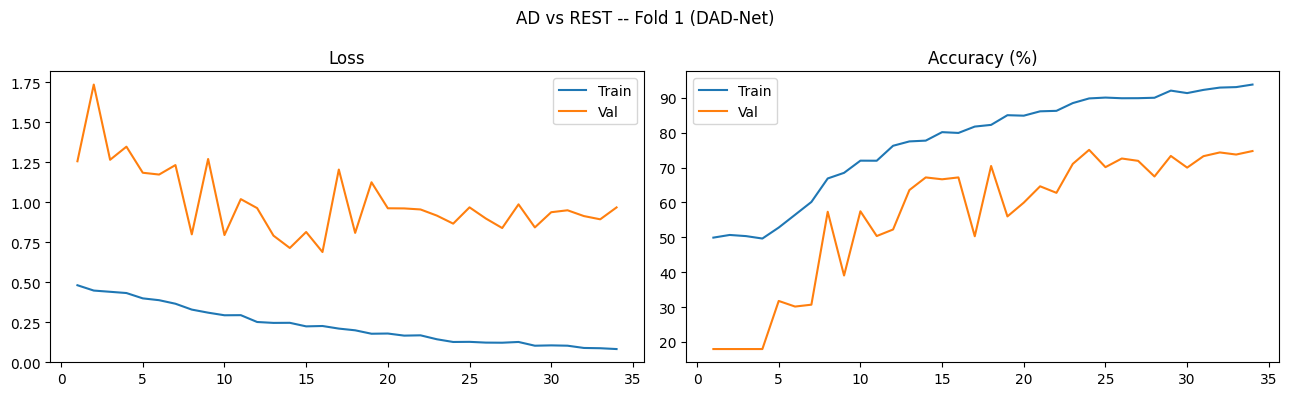

  Fold 1 -- Patient-level val acc: 76.79%

  --- Fold 2/5 ---
  Train -- AD: 982 | REST: 4809 | Val patients: 55


  Ep 01 | train loss=0.4745 acc=51.0% | val loss=1.3838 acc=16.2%
    * Best val_acc=16.16% -- saved.


  Ep 02 | train loss=0.4563 acc=48.9% | val loss=1.1416 acc=16.2%


  Ep 03 | train loss=0.4246 acc=52.7% | val loss=1.3355 acc=23.1%
    * Best val_acc=23.08% -- saved.


  Ep 04 | train loss=0.3920 acc=58.6% | val loss=1.3927 acc=24.2%
    * Best val_acc=24.25% -- saved.


...

  Ep 29 | train loss=0.0743 acc=94.2% | val loss=1.5031 acc=71.5%


  Ep 30 | train loss=0.0751 acc=94.4% | val loss=1.4193 acc=71.6%


  Ep 31 | train loss=0.0710 acc=94.6% | val loss=1.4179 acc=73.1%


  Ep 32 | train loss=0.0584 acc=95.4% | val loss=1.4760 acc=72.6%


  Ep 33 | train loss=0.0644 acc=95.2% | val loss=1.4024 acc=74.0%
    Early stopping at epoch 33.


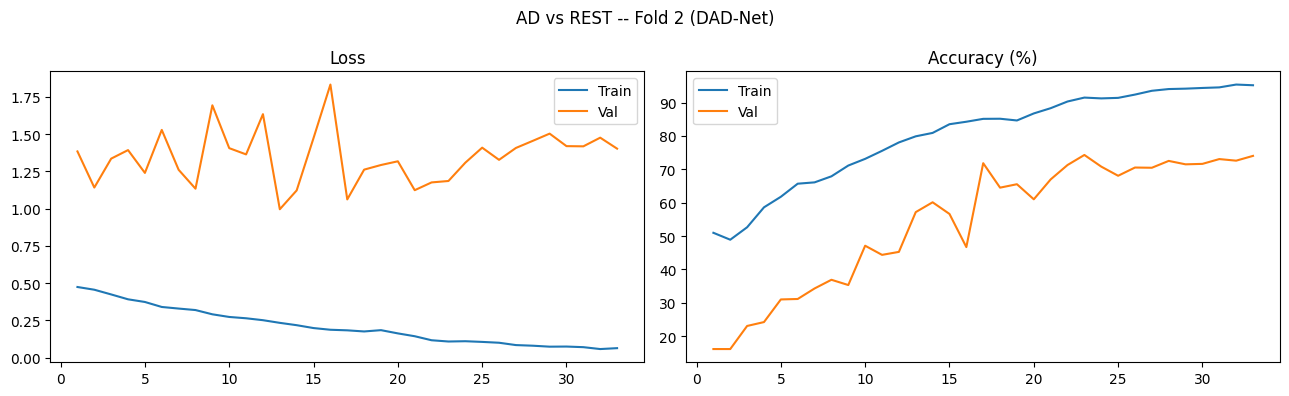

  Fold 2 -- Patient-level val acc: 76.36%

  --- Fold 3/5 ---
  Train -- AD: 977 | REST: 4839 | Val patients: 54


  Ep 01 | train loss=0.4761 acc=50.2% | val loss=1.3026 acc=17.7%
    * Best val_acc=17.70% -- saved.


  Ep 02 | train loss=0.4175 acc=52.6% | val loss=1.1794 acc=24.6%
    * Best val_acc=24.60% -- saved.


  Ep 03 | train loss=0.3779 acc=59.6% | val loss=1.1388 acc=26.4%
    * Best val_acc=26.41% -- saved.


  Ep 04 | train loss=0.3472 acc=64.8% | val loss=1.1709 acc=33.7%
    * Best val_acc=33.66% -- saved.


...

  Ep 34 | train loss=0.0590 acc=95.6% | val loss=2.4675 acc=68.6%


  Ep 35 | train loss=0.0496 acc=96.2% | val loss=2.5043 acc=68.6%


  Ep 36 | train loss=0.0505 acc=96.6% | val loss=2.4909 acc=66.3%


  Ep 37 | train loss=0.0429 acc=96.5% | val loss=2.4989 acc=68.2%


  Ep 38 | train loss=0.0455 acc=96.4% | val loss=2.5753 acc=68.7%
    Early stopping at epoch 38.


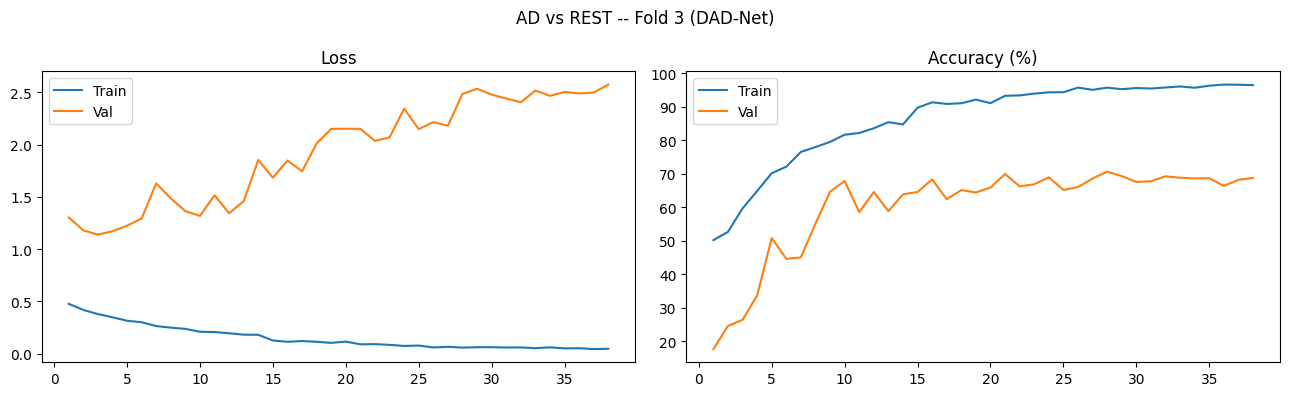

  Fold 3 -- Patient-level val acc: 70.37%

  --- Fold 4/5 ---
  Train -- AD: 975 | REST: 4842 | Val patients: 54


  Ep 01 | train loss=0.4870 acc=49.5% | val loss=1.1924 acc=16.9%
    * Best val_acc=16.95% -- saved.


  Ep 02 | train loss=0.4299 acc=50.6% | val loss=1.3909 acc=17.2%
    * Best val_acc=17.15% -- saved.


  Ep 03 | train loss=0.4171 acc=51.0% | val loss=1.1342 acc=41.8%
    * Best val_acc=41.84% -- saved.


  Ep 04 | train loss=0.3792 acc=58.5% | val loss=1.2435 acc=33.5%


...

  Ep 32 | train loss=0.0599 acc=95.6% | val loss=1.2499 acc=73.1%


  Ep 33 | train loss=0.0479 acc=96.4% | val loss=1.2777 acc=73.0%


  Ep 34 | train loss=0.0520 acc=96.1% | val loss=1.3133 acc=75.7%


  Ep 35 | train loss=0.0425 acc=96.8% | val loss=1.3769 acc=75.0%


  Ep 36 | train loss=0.0462 acc=96.5% | val loss=1.3278 acc=73.7%
    Early stopping at epoch 36.


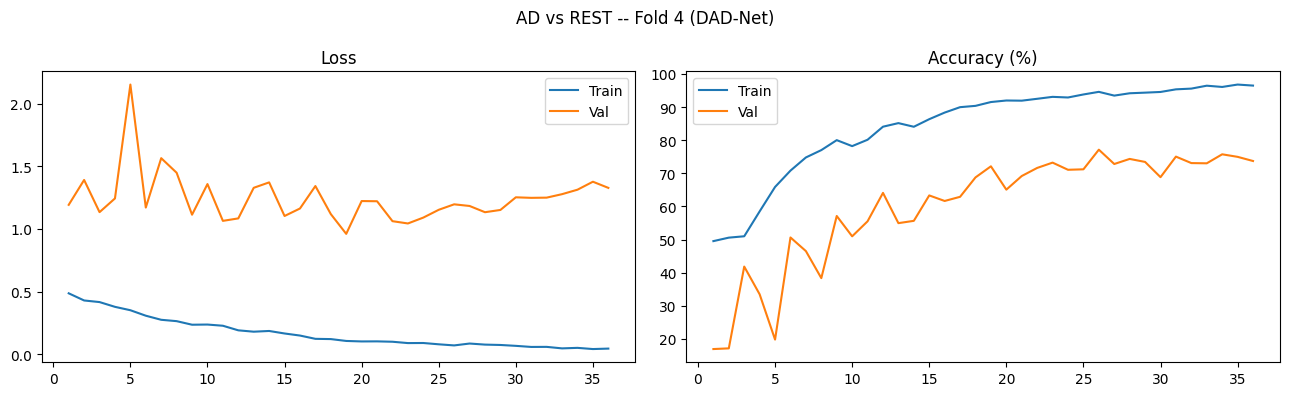

  Fold 4 -- Patient-level val acc: 75.93%

  --- Fold 5/5 ---
  Train -- AD: 988 | REST: 4834 | Val patients: 54


  Ep 01 | train loss=0.4732 acc=49.8% | val loss=1.8025 acc=16.1%
    * Best val_acc=16.10% -- saved.


  Ep 02 | train loss=0.4517 acc=48.4% | val loss=1.3985 acc=16.1%


  Ep 03 | train loss=0.4119 acc=51.3% | val loss=1.9690 acc=16.1%


  Ep 04 | train loss=0.3902 acc=54.4% | val loss=1.8253 acc=20.4%
    * Best val_acc=20.43% -- saved.


...

  Ep 17 | train loss=0.1482 acc=88.7% | val loss=1.4943 acc=55.3%


  Ep 18 | train loss=0.1394 acc=88.9% | val loss=1.3904 acc=58.9%


  Ep 19 | train loss=0.1386 acc=89.4% | val loss=1.5585 acc=54.2%


  Ep 20 | train loss=0.1245 acc=89.9% | val loss=1.5091 acc=55.9%


  Ep 21 | train loss=0.1102 acc=91.3% | val loss=1.4611 acc=58.3%
    Early stopping at epoch 21.


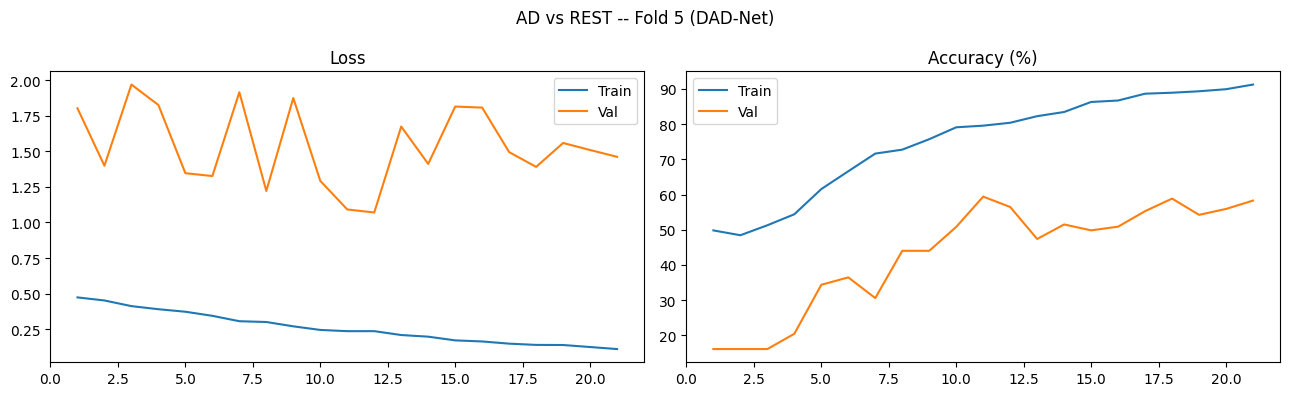

  Fold 5 -- Patient-level val acc: 59.26%

  AD vs REST -- CV: 71.74% +/- 6.66%

  CN vs REST  --  5-Fold CV  (DAD-Net)

  --- Fold 1/5 ---
  Train -- CN: 1589 | REST: 4169 | Val patients: 56


  Ep 01 | train loss=0.6192 acc=50.9% | val loss=0.9635 acc=27.0%
    * Best val_acc=26.99% -- saved.


  Ep 02 | train loss=0.5683 acc=51.6% | val loss=0.9024 acc=27.0%


  Ep 03 | train loss=0.5544 acc=51.8% | val loss=1.3175 acc=27.3%
    * Best val_acc=27.26% -- saved.


  Ep 04 | train loss=0.5268 acc=60.0% | val loss=1.3232 acc=27.1%


...

  Ep 16 | train loss=0.2845 acc=83.3% | val loss=1.1102 acc=57.0%


  Ep 17 | train loss=0.2642 acc=84.3% | val loss=1.0873 acc=56.1%


  Ep 18 | train loss=0.2654 acc=85.0% | val loss=1.2597 acc=54.6%


  Ep 19 | train loss=0.2462 acc=85.9% | val loss=1.2345 acc=53.9%


  Ep 20 | train loss=0.2268 acc=87.1% | val loss=1.0992 acc=57.6%
    Early stopping at epoch 20.


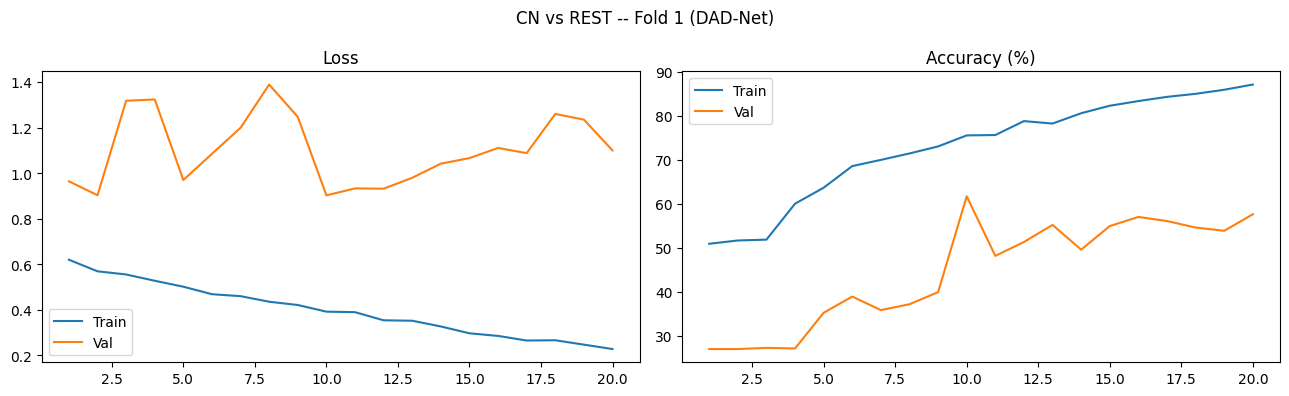

  Fold 1 -- Patient-level val acc: 60.71%

  --- Fold 2/5 ---
  Train -- CN: 1591 | REST: 4200 | Val patients: 55


  Ep 01 | train loss=0.6051 acc=51.6% | val loss=0.9474 acc=27.5%
    * Best val_acc=27.47% -- saved.


  Ep 02 | train loss=0.5869 acc=50.6% | val loss=0.9124 acc=27.5%


  Ep 03 | train loss=0.5811 acc=49.5% | val loss=1.0500 acc=27.5%


  Ep 04 | train loss=0.5591 acc=50.8% | val loss=0.8012 acc=52.7%
    * Best val_acc=52.74% -- saved.


...

  Ep 19 | train loss=0.2844 acc=82.5% | val loss=0.8281 acc=63.9%


  Ep 20 | train loss=0.2728 acc=83.6% | val loss=0.8437 acc=64.3%


  Ep 21 | train loss=0.2445 acc=85.8% | val loss=1.0481 acc=60.6%


  Ep 22 | train loss=0.2341 acc=86.0% | val loss=1.0705 acc=59.1%


  Ep 23 | train loss=0.2089 acc=88.1% | val loss=1.0406 acc=60.7%
    Early stopping at epoch 23.


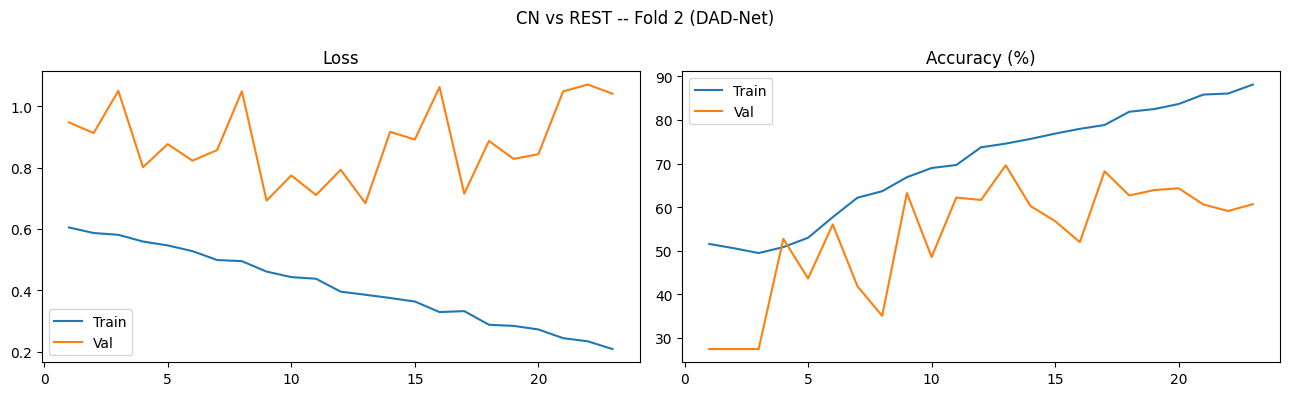

  Fold 2 -- Patient-level val acc: 70.91%

  --- Fold 3/5 ---
  Train -- CN: 1602 | REST: 4214 | Val patients: 54


  Ep 01 | train loss=0.6133 acc=50.4% | val loss=1.1635 acc=27.2%
    * Best val_acc=27.18% -- saved.


  Ep 02 | train loss=0.5821 acc=50.9% | val loss=1.1360 acc=27.2%


  Ep 03 | train loss=0.5673 acc=51.2% | val loss=1.3335 acc=28.5%
    * Best val_acc=28.50% -- saved.


  Ep 04 | train loss=0.5515 acc=55.5% | val loss=0.9311 acc=37.3%
    * Best val_acc=37.28% -- saved.


...

  Ep 33 | train loss=0.1439 acc=92.4% | val loss=1.3047 acc=62.6%


  Ep 34 | train loss=0.1332 acc=93.0% | val loss=1.3498 acc=60.3%


  Ep 35 | train loss=0.1391 acc=92.5% | val loss=1.3406 acc=61.2%


  Ep 36 | train loss=0.1264 acc=93.4% | val loss=1.3035 acc=62.7%


  Ep 37 | train loss=0.1269 acc=93.3% | val loss=1.3626 acc=62.3%
    Early stopping at epoch 37.


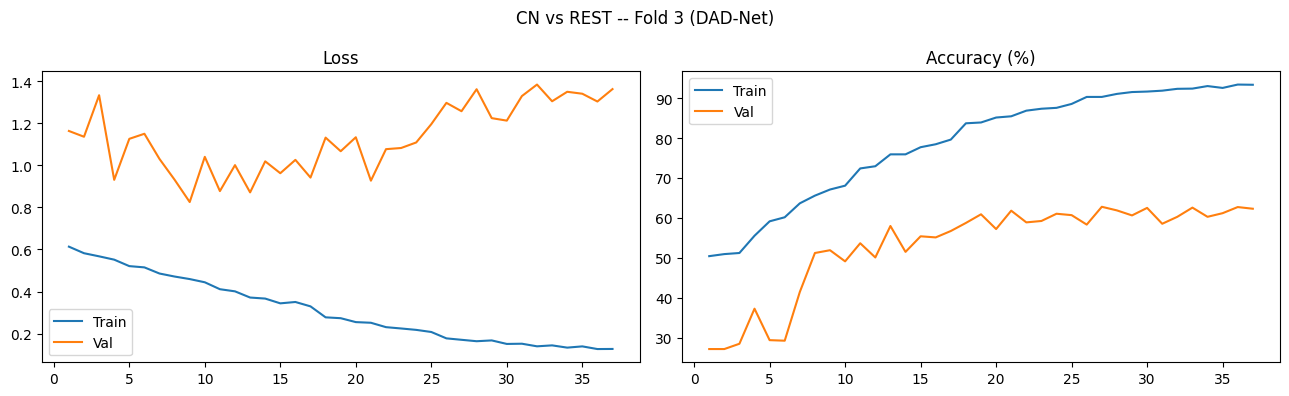

  Fold 3 -- Patient-level val acc: 64.81%

  --- Fold 4/5 ---
  Train -- CN: 1591 | REST: 4226 | Val patients: 54


  Ep 01 | train loss=0.6060 acc=50.5% | val loss=1.0626 acc=28.0%
    * Best val_acc=27.96% -- saved.


  Ep 02 | train loss=0.5674 acc=51.5% | val loss=0.9307 acc=38.1%
    * Best val_acc=38.15% -- saved.


  Ep 03 | train loss=0.5410 acc=56.6% | val loss=0.8406 acc=33.5%


  Ep 04 | train loss=0.5247 acc=58.8% | val loss=0.9099 acc=45.3%
    * Best val_acc=45.33% -- saved.


...

  Ep 36 | train loss=0.1334 acc=93.0% | val loss=1.6041 acc=66.0%


  Ep 37 | train loss=0.1537 acc=91.8% | val loss=1.4229 acc=65.4%


  Ep 38 | train loss=0.1319 acc=92.8% | val loss=1.6182 acc=67.6%


  Ep 39 | train loss=0.1190 acc=93.7% | val loss=1.6589 acc=67.6%


  Ep 40 | train loss=0.1181 acc=93.7% | val loss=1.7421 acc=68.0%


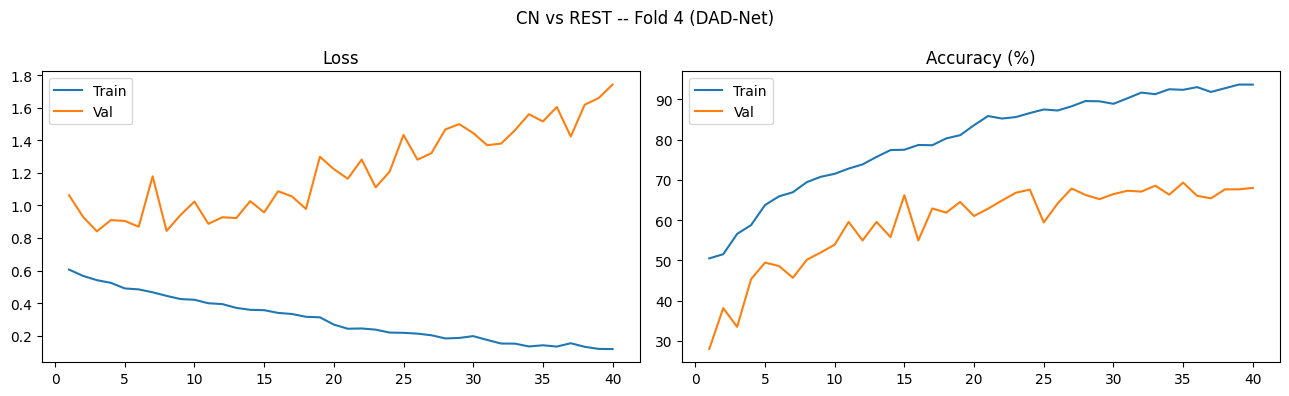

  Fold 4 -- Patient-level val acc: 68.52%

  --- Fold 5/5 ---
  Train -- CN: 1595 | REST: 4227 | Val patients: 54


  Ep 01 | train loss=0.6275 acc=48.9% | val loss=0.8593 acc=27.8%
    * Best val_acc=27.78% -- saved.


  Ep 02 | train loss=0.5923 acc=50.5% | val loss=0.9531 acc=27.8%


  Ep 03 | train loss=0.5825 acc=50.8% | val loss=1.1591 acc=27.8%


  Ep 04 | train loss=0.5768 acc=50.4% | val loss=0.8981 acc=27.9%
    * Best val_acc=27.85% -- saved.


...

  Ep 36 | train loss=0.1503 acc=91.4% | val loss=1.2058 acc=61.4%


  Ep 37 | train loss=0.1569 acc=91.3% | val loss=1.1888 acc=62.4%


  Ep 38 | train loss=0.1550 acc=91.3% | val loss=1.1958 acc=60.7%


  Ep 39 | train loss=0.1477 acc=91.9% | val loss=1.2150 acc=60.5%


  Ep 40 | train loss=0.1501 acc=91.5% | val loss=1.1954 acc=61.9%


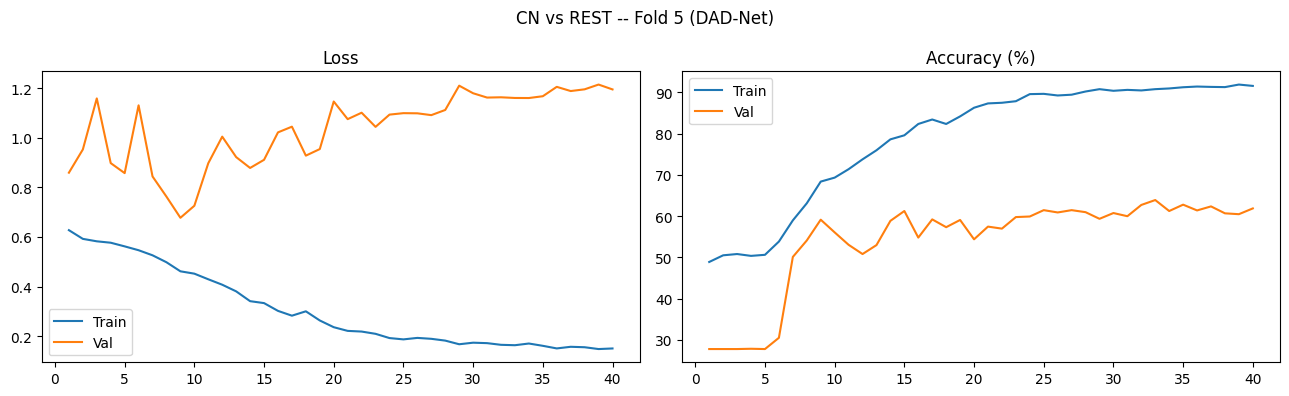

  Fold 5 -- Patient-level val acc: 62.96%

  CN vs REST -- CV: 65.58% +/- 3.69%

  MCI vs REST  --  5-Fold CV  (DAD-Net)

  --- Fold 1/5 ---
  Train -- MCI: 3219 | REST: 2539 | Val patients: 56


  Ep 01 | train loss=0.7005 acc=51.4% | val loss=0.6968 acc=48.5%
    * Best val_acc=48.49% -- saved.


  Ep 02 | train loss=0.6822 acc=52.2% | val loss=0.7304 acc=44.7%


  Ep 03 | train loss=0.6767 acc=53.7% | val loss=0.7139 acc=50.2%
    * Best val_acc=50.23% -- saved.


  Ep 04 | train loss=0.6707 acc=55.1% | val loss=0.7087 acc=50.8%
    * Best val_acc=50.77% -- saved.


...

  Ep 10 | train loss=0.5700 acc=67.3% | val loss=0.8383 acc=40.5%


  Ep 11 | train loss=0.5461 acc=69.1% | val loss=0.8423 acc=48.5%


  Ep 12 | train loss=0.5275 acc=71.6% | val loss=0.8996 acc=46.3%


  Ep 13 | train loss=0.5149 acc=72.8% | val loss=0.8875 acc=47.9%


  Ep 14 | train loss=0.4906 acc=74.2% | val loss=0.8870 acc=45.2%
    Early stopping at epoch 14.


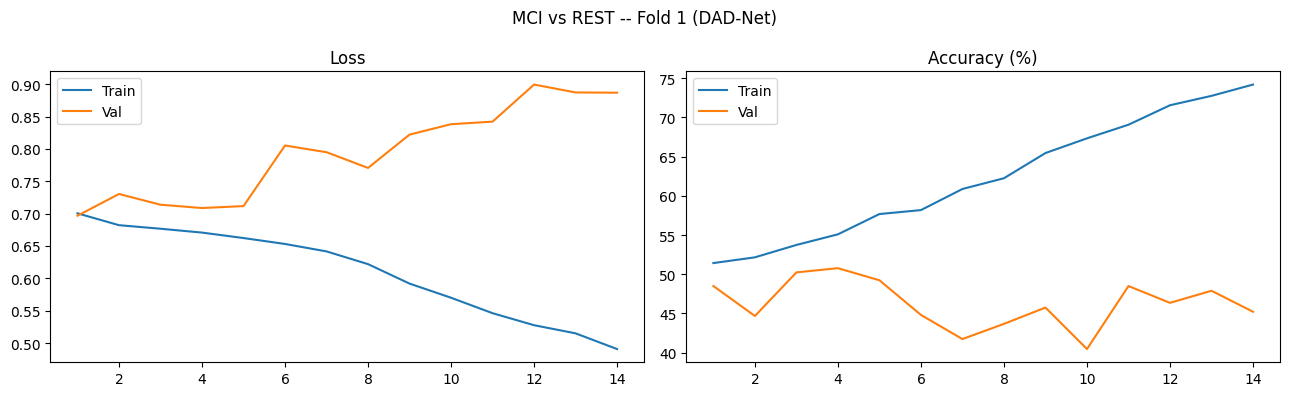

  Fold 1 -- Patient-level val acc: 55.36%

  --- Fold 2/5 ---
  Train -- MCI: 3218 | REST: 2573 | Val patients: 55


  Ep 01 | train loss=0.7727 acc=50.2% | val loss=0.6922 acc=56.8%
    * Best val_acc=56.78% -- saved.


  Ep 02 | train loss=0.6824 acc=52.1% | val loss=0.7303 acc=46.7%


  Ep 03 | train loss=0.6783 acc=53.2% | val loss=0.7283 acc=49.7%


  Ep 04 | train loss=0.6713 acc=55.3% | val loss=0.7721 acc=43.9%


...

  Ep 16 | train loss=0.5526 acc=69.4% | val loss=0.7925 acc=51.4%


  Ep 17 | train loss=0.5462 acc=70.1% | val loss=0.7999 acc=52.6%


  Ep 18 | train loss=0.5376 acc=71.1% | val loss=0.8312 acc=55.5%


  Ep 19 | train loss=0.5293 acc=71.8% | val loss=0.8441 acc=54.9%


  Ep 20 | train loss=0.5087 acc=73.9% | val loss=0.9034 acc=53.7%
    Early stopping at epoch 20.


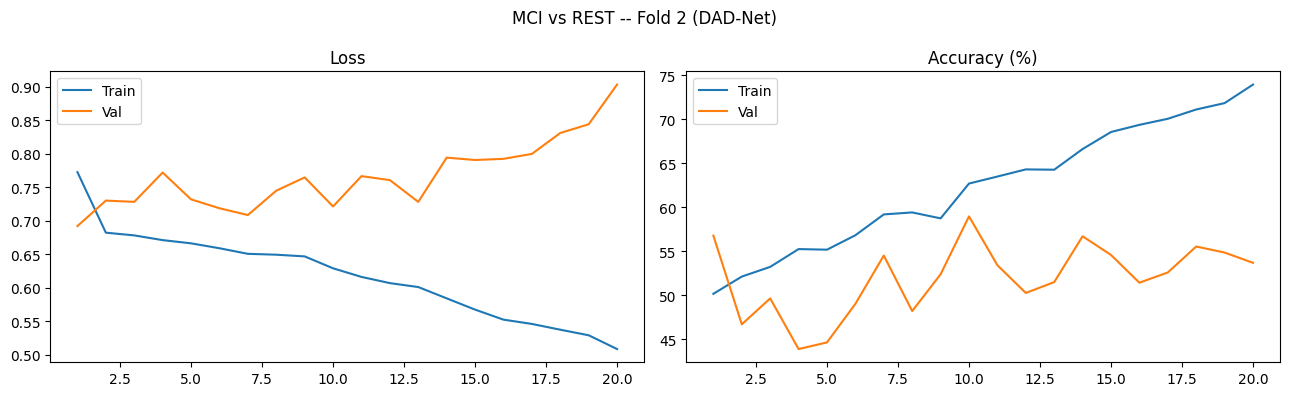

  Fold 2 -- Patient-level val acc: 60.00%

  --- Fold 3/5 ---
  Train -- MCI: 3237 | REST: 2579 | Val patients: 54


  Ep 01 | train loss=0.7092 acc=49.8% | val loss=0.6999 acc=44.0%
    * Best val_acc=43.97% -- saved.


  Ep 02 | train loss=0.6874 acc=50.4% | val loss=0.7020 acc=44.2%
    * Best val_acc=44.18% -- saved.


  Ep 03 | train loss=0.6840 acc=50.1% | val loss=0.7182 acc=44.1%


  Ep 04 | train loss=0.6828 acc=50.7% | val loss=0.7188 acc=44.0%


...

  Ep 11 | train loss=0.5796 acc=66.5% | val loss=0.9283 acc=46.0%


  Ep 12 | train loss=0.5399 acc=70.0% | val loss=0.9685 acc=50.8%


  Ep 13 | train loss=0.5290 acc=71.1% | val loss=1.1052 acc=46.5%


  Ep 14 | train loss=0.5062 acc=73.0% | val loss=1.1795 acc=45.4%


  Ep 15 | train loss=0.4778 acc=75.1% | val loss=1.3047 acc=47.7%
    Early stopping at epoch 15.


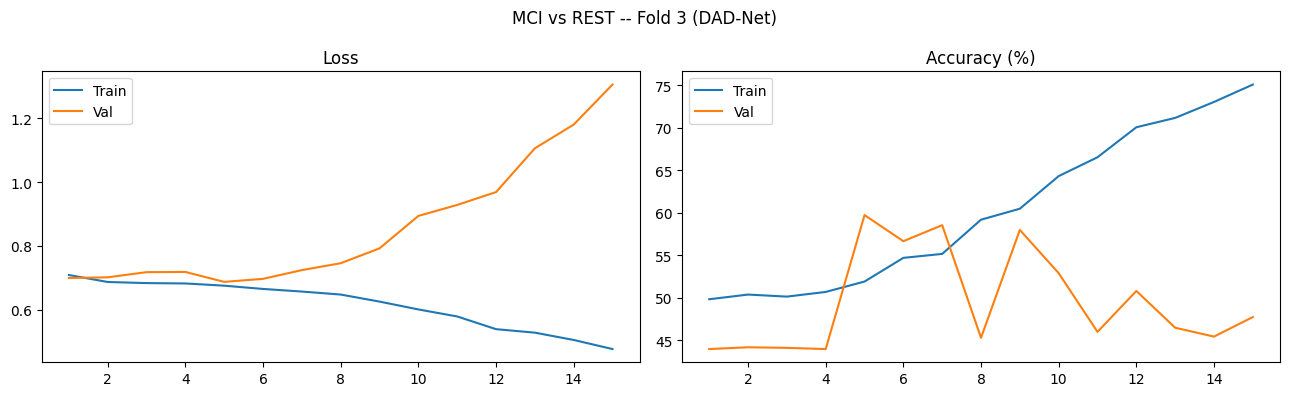

  Fold 3 -- Patient-level val acc: 57.41%

  --- Fold 4/5 ---
  Train -- MCI: 3251 | REST: 2566 | Val patients: 54


  Ep 01 | train loss=0.7053 acc=51.0% | val loss=0.7013 acc=44.9%
    * Best val_acc=44.91% -- saved.


  Ep 02 | train loss=0.6859 acc=49.9% | val loss=0.7076 acc=44.9%


  Ep 03 | train loss=0.6781 acc=52.1% | val loss=0.7292 acc=50.1%
    * Best val_acc=50.14% -- saved.


  Ep 04 | train loss=0.6686 acc=53.9% | val loss=0.7575 acc=43.4%


...

  Ep 14 | train loss=0.5687 acc=67.6% | val loss=0.8859 acc=47.0%


  Ep 15 | train loss=0.5629 acc=68.2% | val loss=0.8903 acc=47.1%


  Ep 16 | train loss=0.5370 acc=71.4% | val loss=0.9046 acc=50.4%


  Ep 17 | train loss=0.5286 acc=71.8% | val loss=0.9418 acc=45.3%


  Ep 18 | train loss=0.5034 acc=74.4% | val loss=1.0113 acc=49.5%
    Early stopping at epoch 18.


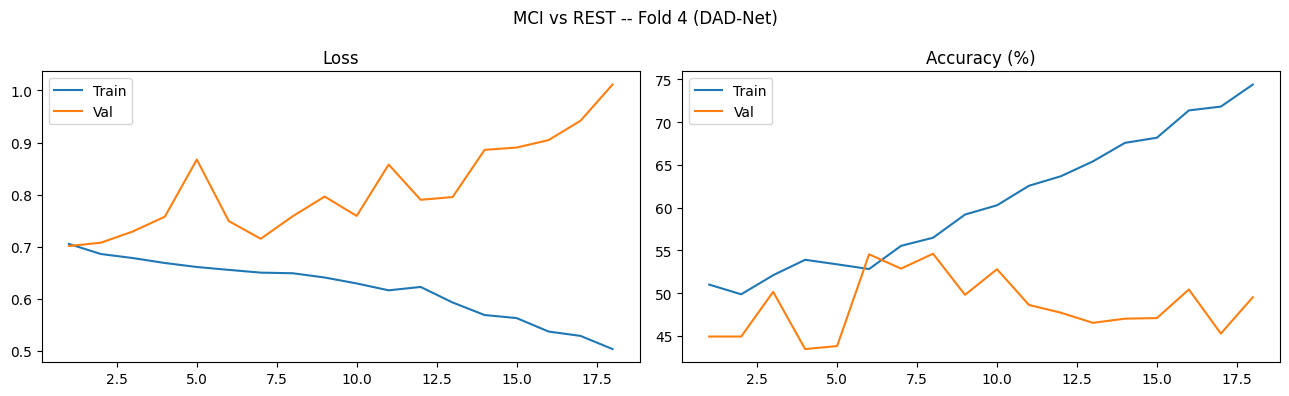

  Fold 4 -- Patient-level val acc: 55.56%

  --- Fold 5/5 ---
  Train -- MCI: 3239 | REST: 2583 | Val patients: 54


  Ep 01 | train loss=0.7173 acc=51.3% | val loss=0.6941 acc=45.3%
    * Best val_acc=45.35% -- saved.


  Ep 02 | train loss=0.6862 acc=50.1% | val loss=0.7121 acc=44.1%


  Ep 03 | train loss=0.6842 acc=52.2% | val loss=0.7122 acc=51.0%
    * Best val_acc=51.01% -- saved.


  Ep 04 | train loss=0.6778 acc=54.8% | val loss=0.7705 acc=42.8%


...

  Ep 09 | train loss=0.5862 acc=68.1% | val loss=0.8385 acc=45.6%


  Ep 10 | train loss=0.5832 acc=67.1% | val loss=0.7975 acc=49.9%


  Ep 11 | train loss=0.5516 acc=70.3% | val loss=0.8097 acc=49.3%


  Ep 12 | train loss=0.5299 acc=72.2% | val loss=0.8537 acc=48.1%


  Ep 13 | train loss=0.5151 acc=73.2% | val loss=0.9447 acc=46.0%
    Early stopping at epoch 13.


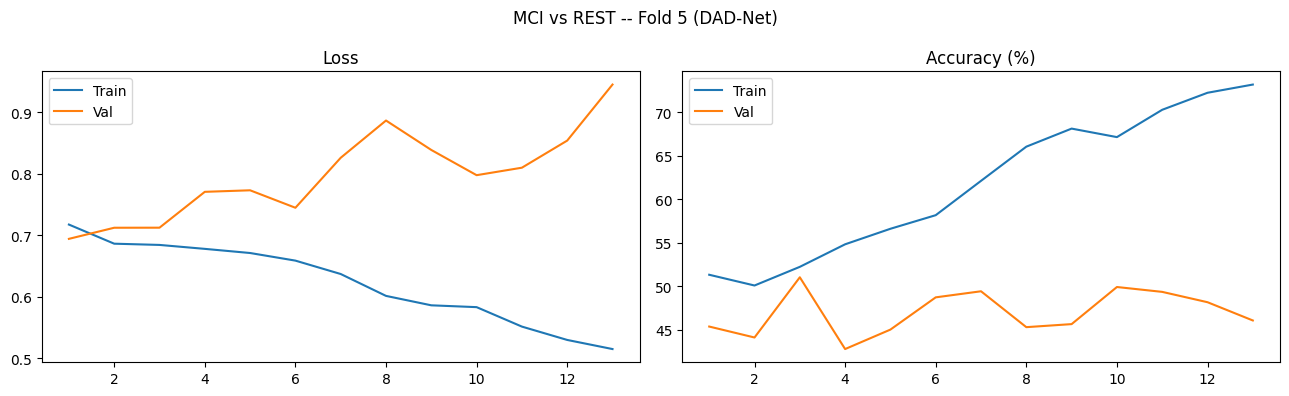

  Fold 5 -- Patient-level val acc: 51.85%

  MCI vs REST -- CV: 56.03% +/- 2.68%

All folds done.


In [11]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)
for cls in CLASS_NAMES: random.shuffle(trainval_by_class[cls])

fold_results    = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}
all_fold_ckpts  = {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f'\n{"="*68}')
    print(f'  {pos_name} vs REST  --  {N_FOLDS}-Fold CV  (DAD-Net)')
    print(f'{"="*68}')

    class_folds = {cls: [trainval_by_class[cls][i::N_FOLDS] for i in range(N_FOLDS)]
                   for cls in CLASS_NAMES}

    for fold_idx in range(N_FOLDS):
        print(f'\n  --- Fold {fold_idx+1}/{N_FOLDS} ---')
        val_pids, train_pids = [], []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                (val_pids if k == fold_idx else train_pids).extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                c = clean_patients[pid]; l = CLASS_NAMES.index(c)
                for path in patient_slices[(pid, c)]: out.append((path, l, pid))
            return out

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in entries]

        train_bin = binarize(expand(train_pids))
        val_bin   = binarize(expand(val_pids))
        train_ds  = SliceDataset(train_bin, augment=True)
        val_ds    = SliceDataset(val_bin,   augment=False)

        if len(train_ds) == 0:
            raise RuntimeError(f'Fold {fold_idx+1} ({pos_name}): train_ds empty. Re-run Cell 7.')

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f'  Train -- {pos_name}: {pos_count} | REST: {neg_count} | Val patients: {len(val_pids)}')

        cls_counts = Counter(train_ds.get_labels())
        weights    = [1.0 / cls_counts[l] for l in train_ds.get_labels()]
        sampler    = WeightedRandomSampler(weights, len(weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                  num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)

        model = build_dad_net(num_classes=2).to(device)

        total_train   = pos_count + neg_count
        class_weights = torch.tensor(
            [total_train / (2.0 * neg_count), total_train / (2.0 * pos_count)],
            dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, fused=False)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        scaler    = torch.amp.GradScaler()

        ckpt_path = os.path.join(CKPT_DIR, f'fold{fold_idx+1}_{pos_name}_vs_REST.pt')
        best_val_acc, patience_ctr = 0.0, 0
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(1, NUM_EPOCHS + 1):
            tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, scaler,
                                        desc=f'Ep{epoch}/{NUM_EPOCHS} [train]')
            vl_loss, vl_acc = run_epoch(val_loader, model, criterion,
                                        desc=f'Ep{epoch}/{NUM_EPOCHS} [val  ]')
            history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
            history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
            scheduler.step(vl_acc)
            print(f'  Ep {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.1f}% | '
                  f'val loss={vl_loss:.4f} acc={vl_acc*100:.1f}%')
            if vl_acc > best_val_acc:
                best_val_acc = vl_acc; torch.save(model.state_dict(), ckpt_path); patience_ctr = 0
                print(f'    * Best val_acc={best_val_acc*100:.2f}% -- saved.')
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE: print(f'    Early stopping at epoch {epoch}.'); break

        ep = range(1, len(history['train_loss']) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f'{pos_name} vs REST -- Fold {fold_idx+1} (DAD-Net)')
        axes[0].plot(ep, history['train_loss'], label='Train')
        axes[0].plot(ep, history['val_loss'], label='Val')
        axes[0].set_title('Loss'); axes[0].legend()
        axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
        axes[1].plot(ep, [a*100 for a in history['val_acc']], label='Val')
        axes[1].set_title('Accuracy (%)'); axes[1].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(CKPT_DIR, f'curves_fold{fold_idx+1}_{pos_name}_vs_REST.png'), dpi=120)
        plt.show()

        model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
        pat_acc, _, _ = patient_level_eval(val_loader, model, num_classes=2)
        print(f'  Fold {fold_idx+1} -- Patient-level val acc: {pat_acc*100:.2f}%')
        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)
        model.to('cpu').eval(); all_fold_models[pos_name].append(model)
        del optimizer, scaler, train_ds, val_ds; torch.cuda.empty_cache()

    print(f'\n  {pos_name} vs REST -- CV: '
          f'{np.mean(fold_results[pos_name])*100:.2f}% +/- {np.std(fold_results[pos_name])*100:.2f}%')

print('\nAll folds done.')

## Cell 12 — Weighted Ensemble Test Evaluation (Binary, Patient-Level)

  WEIGHTED ENSEMBLE -- HOLD-OUT TEST (DAD-Net)

  AD vs REST
    Fold 1: val_acc=76.79%  weight=0.2141
    Fold 2: val_acc=76.36%  weight=0.2129
    Fold 3: val_acc=70.37%  weight=0.1962
    Fold 4: val_acc=75.93%  weight=0.2117
    Fold 5: val_acc=59.26%  weight=0.1652



  Test Acc (AD vs REST): 74.47%  [47 patients]
              precision    recall  f1-score   support

        REST       0.86      0.82      0.84        39
          AD       0.30      0.38      0.33         8

    accuracy                           0.74        47
   macro avg       0.58      0.60      0.59        47
weighted avg       0.77      0.74      0.76        47



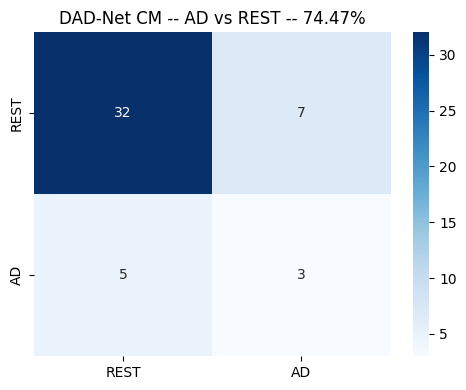


  CN vs REST
    Fold 1: val_acc=60.71%  weight=0.1851
    Fold 2: val_acc=70.91%  weight=0.2162
    Fold 3: val_acc=64.81%  weight=0.1977
    Fold 4: val_acc=68.52%  weight=0.2089
    Fold 5: val_acc=62.96%  weight=0.1920



  Test Acc (CN vs REST): 76.60%  [47 patients]
              precision    recall  f1-score   support

        REST       0.79      0.91      0.85        34
          CN       0.62      0.38      0.48        13

    accuracy                           0.77        47
   macro avg       0.71      0.65      0.66        47
weighted avg       0.75      0.77      0.75        47



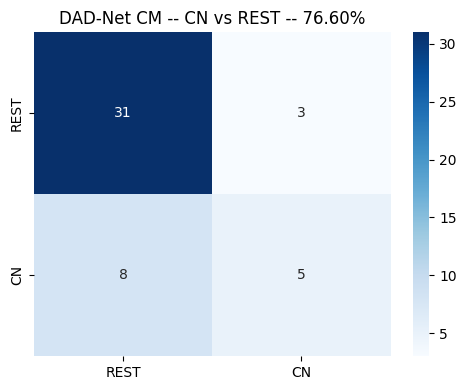


  MCI vs REST
    Fold 1: val_acc=55.36%  weight=0.1976
    Fold 2: val_acc=60.00%  weight=0.2142
    Fold 3: val_acc=57.41%  weight=0.2049
    Fold 4: val_acc=55.56%  weight=0.1983
    Fold 5: val_acc=51.85%  weight=0.1851



  Test Acc (MCI vs REST): 51.06%  [47 patients]
              precision    recall  f1-score   support

        REST       0.46      0.57      0.51        21
         MCI       0.57      0.46      0.51        26

    accuracy                           0.51        47
   macro avg       0.52      0.52      0.51        47
weighted avg       0.52      0.51      0.51        47



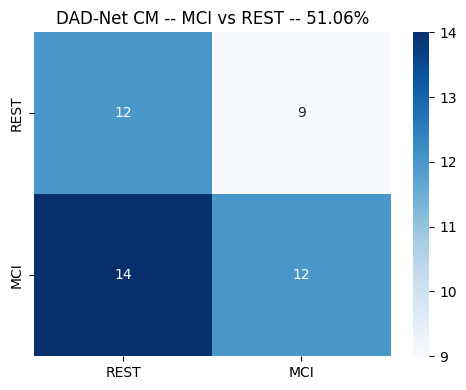

In [12]:
final_results = {}
print('='*68); print('  WEIGHTED ENSEMBLE -- HOLD-OUT TEST (DAD-Net)'); print('='*68)

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ['REST', pos_name]
    test_bin     = [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in test_entries]
    test_ds      = SliceDataset(test_bin, augment=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    print(f'\n  {pos_name} vs REST')
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f'    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}')

    fold_models = all_fold_models[pos_name]
    for m in fold_models: m.to(device).eval()

    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}
    with torch.no_grad():
        for images, labels, pids in tqdm(test_loader, desc=f'{pos_name} -- Ensemble', leave=False):
            images = images.to(device, non_blocking=True)
            batch_wp = np.zeros((images.size(0), 2))
            for fm, w in zip(fold_models, fold_weights):
                with torch.amp.autocast(device_type='cuda'): logits = fm(images)
                batch_wp += w * torch.softmax(logits, dim=1).cpu().numpy()
            for wp, lbl, pid in zip(batch_wp, labels.numpy(), pids):
                patient_probs[pid] += wp; patient_labels[pid] = int(lbl)

    all_true, all_pred = [], []
    for pid, wp in patient_probs.items():
        all_true.append(patient_labels[pid]); all_pred.append(int(np.argmax(wp)))

    pat_acc = float(np.mean(np.array(all_true) == np.array(all_pred)))
    print(f'\n  Test Acc ({pos_name} vs REST): {pat_acc*100:.2f}%  [{len(patient_probs)} patients]')
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=binary_names, yticklabels=binary_names)
    plt.title(f'DAD-Net CM -- {pos_name} vs REST -- {pat_acc*100:.2f}%')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'cm_{pos_name}_vs_REST.png'), dpi=150); plt.show()

    final_results[pos_name] = {
        'patient_test_acc': pat_acc,
        'cv_mean_acc': float(np.mean(fold_accs)),
        'cv_std_acc':  float(np.std(fold_accs)),
        'fold_weights': fold_weights.tolist(),
    }
    for m in fold_models: m.to('cpu')
    torch.cuda.empty_cache()

## Cell 13 — OVA Multi-Class Prediction on Hold-Out Test Set

  OVA MULTI-CLASS -- HOLD-OUT TEST (DAD-Net)
  Accuracy: 48.94%  [47 patients]
              precision    recall  f1-score   support

          AD       0.23      0.38      0.29         8
          CN       0.62      0.38      0.48        13
         MCI       0.58      0.58      0.58        26

    accuracy                           0.49        47
   macro avg       0.48      0.45      0.45        47
weighted avg       0.53      0.49      0.50        47



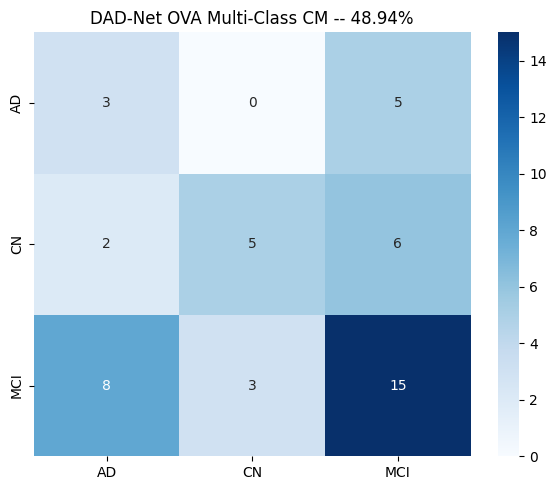

In [13]:
full_test_ds     = SliceDataset(test_entries, augment=False)
full_test_loader = DataLoader(full_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

ova_probs  = defaultdict(lambda: {c: 0.0 for c in CLASS_NAMES})
ova_labels = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    fold_models  = all_fold_models[pos_name]
    for m in fold_models: m.to(device).eval()
    with torch.no_grad():
        for images, labels, pids in tqdm(full_test_loader, desc=f'OVA [{pos_name}]', leave=False):
            images = images.to(device, non_blocking=True)
            batch_pos = np.zeros(images.size(0))
            for fm, w in zip(fold_models, fold_weights):
                with torch.amp.autocast(device_type='cuda'): logits = fm(images)
                batch_pos += w * torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            for pos_p, lbl, pid in zip(batch_pos, labels.numpy(), pids):
                ova_probs[pid][pos_name] += float(pos_p); ova_labels[pid] = int(lbl)
    for m in fold_models: m.to('cpu')
    torch.cuda.empty_cache()

ova_true, ova_pred = [], []
for pid, conf in ova_probs.items():
    ova_pred.append(CLASS_NAMES.index(max(conf, key=conf.get)))
    ova_true.append(ova_labels[pid])

ova_acc = float(np.mean(np.array(ova_true) == np.array(ova_pred)))
print('='*68); print('  OVA MULTI-CLASS -- HOLD-OUT TEST (DAD-Net)'); print('='*68)
print(f'  Accuracy: {ova_acc*100:.2f}%  [{len(ova_true)} patients]')
print(classification_report(ova_true, ova_pred, target_names=CLASS_NAMES))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(ova_true, ova_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'DAD-Net OVA Multi-Class CM -- {ova_acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'cm_ova_multiclass.png'), dpi=150); plt.show()

## Cell 14 — Final Summary & Export

  FINAL SUMMARY -- DAD-Net (Weighted Ensemble, 1-vs-All)
  Class    CV Acc (mean+/-std)        Ensemble Test Acc
  ------------------------------------------------------------
  AD       71.74% +/- 6.66%           74.47%
  CN       65.58% +/- 3.69%           76.60%
  MCI      56.03% +/- 2.68%           51.06%

  OVA Multi-Class Test Acc: 48.94%  [47 patients]


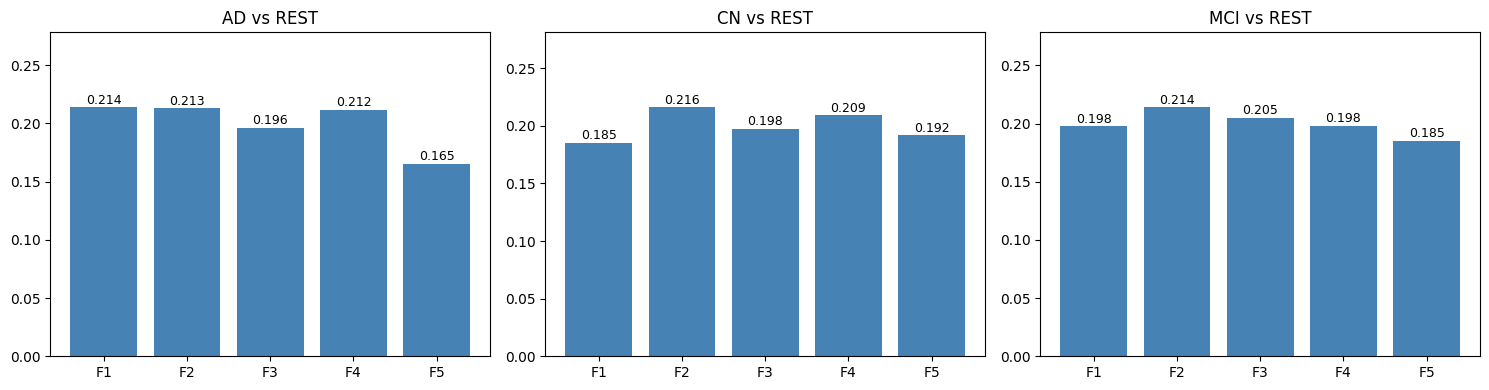

Results saved -> /kaggle/working/checkpoints/results_dadnet.csv
Done!


In [14]:
print('='*72)
print('  FINAL SUMMARY -- DAD-Net (Weighted Ensemble, 1-vs-All)')
print('='*72)
print(f'  {"Class":<8} {"CV Acc (mean+/-std)":<26} {"Ensemble Test Acc"}')
print(f'  {"-"*60}')
for cls, res in final_results.items():
    cv = f'{res["cv_mean_acc"]*100:.2f}% +/- {res["cv_std_acc"]*100:.2f}%'
    t  = f'{res["patient_test_acc"]*100:.2f}%'
    print(f'  {cls:<8} {cv:<26} {t}')
print(f'\n  OVA Multi-Class Test Acc: {ova_acc*100:.2f}%  [{len(ova_true)} patients]')
print('='*72)

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(5*len(CLASS_NAMES), 4))
for ax, cls in zip(axes, CLASS_NAMES):
    wts = final_results[cls]['fold_weights']
    ax.bar([f'F{i+1}' for i in range(len(wts))], wts, color='steelblue')
    ax.set_title(f'{cls} vs REST'); ax.set_ylim(0, max(wts)*1.3)
    for i, w in enumerate(wts): ax.text(i, w+0.003, f'{w:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'fold_weights.png'), dpi=120); plt.show()

csv_path = os.path.join(CKPT_DIR, 'results_dadnet.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'class','cv_mean_acc_%','cv_std_%','ensemble_test_acc_%','fold_weights','n_folds'])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({'class': cls,
                         'cv_mean_acc_%':       round(res['cv_mean_acc']*100, 2),
                         'cv_std_%':            round(res['cv_std_acc']*100, 2),
                         'ensemble_test_acc_%': round(res['patient_test_acc']*100, 2),
                         'fold_weights':        str([round(w,4) for w in res['fold_weights']]),
                         'n_folds': N_FOLDS})
    writer.writerow({'class': 'OVA_MultiClass', 'cv_mean_acc_%': 'N/A', 'cv_std_%': 'N/A',
                     'ensemble_test_acc_%': round(ova_acc*100, 2),
                     'fold_weights': 'N/A', 'n_folds': N_FOLDS})
print(f'Results saved -> {csv_path}')
print('Done!')

## Cell 15 — Save Models & Weights

Consolidates all fold checkpoints into a single `dadnet_saved/` directory with a `metadata.json` (class names, image size, fold weights, val/test results) and zips everything for download.

**What is saved:**
- `{CLASS}_vs_REST_fold{N}.pt` — `state_dict` for each of the 15 fold models (3 classifiers × 5 folds)
- `metadata.json` — all config and results needed to reload without retraining

In [15]:
import shutil, json

SAVE_DIR = '/kaggle/working/dadnet_saved'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save each fold's state_dict ───────────────────────────────────────
for pos_name in CLASS_NAMES:
    for fold_idx, model in enumerate(all_fold_models[pos_name]):
        fname    = f'{pos_name}_vs_REST_fold{fold_idx+1}.pt'
        out_path = os.path.join(SAVE_DIR, fname)
        torch.save(model.state_dict(), out_path)
        size_mb = os.path.getsize(out_path) / 1e6
        print(f'Saved: {fname}  ({size_mb:.1f} MB)')

# ── 2. Save metadata JSON ────────────────────────────────────────────────
metadata = {
    'model':        'DAD-Net',
    'class_names':  CLASS_NAMES,
    'image_size':   IMAGE_SIZE,
    'dropout_rate': DROPOUT_RATE,
    'n_folds':      N_FOLDS,
    'approach':     '1-vs-All binary classifiers',
    'fold_val_accs': {cls: fold_results[cls] for cls in CLASS_NAMES},
    'fold_weights':  {
        cls: (np.array(fold_results[cls]) /
              np.array(fold_results[cls]).sum()).tolist()
        for cls in CLASS_NAMES
    },
    'checkpoint_files': {
        cls: [f'{cls}_vs_REST_fold{k+1}.pt' for k in range(N_FOLDS)]
        for cls in CLASS_NAMES
    },
    'test_results': {
        cls: {
            'cv_mean_acc_%': round(res['cv_mean_acc'] * 100, 4),
            'cv_std_%':      round(res['cv_std_acc']  * 100, 4),
            'test_acc_%':    round(res['patient_test_acc'] * 100, 4),
        }
        for cls, res in final_results.items()
    },
    'ova_test_acc_%': round(ova_acc * 100, 4),
}

meta_path = os.path.join(SAVE_DIR, 'metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'\nSaved: metadata.json')

# ── 3. Zip everything for Kaggle download ────────────────────────────────
zip_path = '/kaggle/working/dadnet_saved'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
zip_size  = os.path.getsize(zip_path + '.zip') / 1e6
print(f'\nZipped -> dadnet_saved.zip  ({zip_size:.1f} MB)')
print('Download it from Kaggle Output panel.')

Saved: AD_vs_REST_fold1.pt  (4.6 MB)
Saved: AD_vs_REST_fold2.pt  (4.6 MB)
Saved: AD_vs_REST_fold3.pt  (4.6 MB)
Saved: AD_vs_REST_fold4.pt  (4.6 MB)
Saved: AD_vs_REST_fold5.pt  (4.6 MB)
Saved: CN_vs_REST_fold1.pt  (4.6 MB)
Saved: CN_vs_REST_fold2.pt  (4.6 MB)
Saved: CN_vs_REST_fold3.pt  (4.6 MB)
Saved: CN_vs_REST_fold4.pt  (4.6 MB)
Saved: CN_vs_REST_fold5.pt  (4.6 MB)
Saved: MCI_vs_REST_fold1.pt  (4.6 MB)
Saved: MCI_vs_REST_fold2.pt  (4.6 MB)
Saved: MCI_vs_REST_fold3.pt  (4.6 MB)
Saved: MCI_vs_REST_fold4.pt  (4.6 MB)
Saved: MCI_vs_REST_fold5.pt  (4.6 MB)

Saved: metadata.json

Zipped -> dadnet_saved.zip  (65.0 MB)
Download it from Kaggle Output panel.


## Cell 16 — Reload Models for Inference

Run this cell (with `build_dad_net` defined in Cell 9) to reconstruct the full weighted ensemble from the saved checkpoints — no retraining needed.

In [17]:
SAVE_DIR = '/kaggle/working/dadnet_saved'

with open(os.path.join(SAVE_DIR, 'metadata.json')) as f:
    meta = json.load(f)

CLASS_NAMES_LOADED  = meta['class_names']
FOLD_WEIGHTS_LOADED = meta['fold_weights']

loaded_models = {}

for cls in CLASS_NAMES_LOADED:
    loaded_models[cls] = []
    for fname in meta['checkpoint_files'][cls]:
        m = build_dad_net(num_classes=2)
        m.load_state_dict(
            torch.load(os.path.join(SAVE_DIR, fname),
                       map_location=device, weights_only=True)
        )
        m.to(device).eval()
        loaded_models[cls].append(m)
    print(f'Loaded {N_FOLDS} fold-models for  {cls} vs REST')

print('\nAll models reloaded. Fold weights:')
for cls, wts in FOLD_WEIGHTS_LOADED.items():
    print(f'  {cls}: {[round(w,4) for w in wts]}')

print('\nStored results:')
for cls, res in meta['test_results'].items():
    print(f'  {cls:<6}: CV={res["cv_mean_acc_%"]}% '
          f'+/- {res["cv_std_%"]}%  |  Test={res["test_acc_%"]}%')
print(f'  OVA Multi-Class Test: {meta["ova_test_acc_%"]}%')

Loaded 5 fold-models for  AD vs REST
Loaded 5 fold-models for  CN vs REST
Loaded 5 fold-models for  MCI vs REST

All models reloaded. Fold weights:
  AD: [0.2141, 0.2129, 0.1962, 0.2117, 0.1652]
  CN: [0.1851, 0.2162, 0.1977, 0.2089, 0.192]
  MCI: [0.1976, 0.2142, 0.2049, 0.1983, 0.1851]

Stored results:
  AD    : CV=71.741% +/- 6.6634%  |  Test=74.4681%
  CN    : CV=65.5839% +/- 3.6917%  |  Test=76.5957%
  MCI   : CV=56.0344% +/- 2.6755%  |  Test=51.0638%
  OVA Multi-Class Test: 48.9362%


XAI

In [18]:
!pip install captum
!pip install lime 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.8 MB/s eta 0:00:00ta 0:00:01


In [19]:
import torch, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
import torch.nn.functional as F
from torchvision import transforms
from collections import defaultdict

from captum.attr import IntegratedGradients, GradientShap
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
XAI_DIR = '/kaggle/working/dadnet_xai'

os.makedirs(XAI_DIR, exist_ok=True)

In [25]:
def _pick_samples(n_per_class=1):
    """Pick n_per_class correctly-predicted samples from each class."""
    samples = {cls: [] for cls in CLASS_NAMES}

    for pid, conf in ova_probs.items():
        pred_name = max(conf, key=conf.get)
        pred_idx  = CLASS_NAMES.index(pred_name)
        true_idx  = ova_labels[pid]
        true_name = CLASS_NAMES[true_idx]

        if pred_name == true_name and len(samples[true_name]) < n_per_class:
            for imgs, lbls, pids in full_test_loader:
                for img, lbl, p in zip(imgs, lbls, pids):
                    if p == pid:
                        samples[true_name].append((img, true_idx, pid))
                        break
                if samples[true_name] and samples[true_name][-1][2] == pid:
                    break

        if all(len(v) >= n_per_class for v in samples.values()):
            break

    flat = []
    for cls, s_list in samples.items():
        print(f"  {cls}: {len(s_list)} sample(s) found")
        flat.extend(s_list)

    return flat

XAI_SAMPLES = _pick_samples(n_per_class=1)
print(f"\nTotal XAI samples: {len(XAI_SAMPLES)}")
for img, true_idx, pid in XAI_SAMPLES:
    pred_name = max(ova_probs[pid], key=ova_probs[pid].get)
    print(f"  PID: {pid} | True: {CLASS_NAMES[true_idx]} | Pred: {pred_name} | Conf: {ova_probs[pid]}")

  AD: 1 sample(s) found
  CN: 1 sample(s) found
  MCI: 1 sample(s) found

Total XAI samples: 3
  PID: 057_S_6869 | True: AD | Pred: AD | Conf: {'AD': 26.279601106503033, 'CN': 7.388971451269584, 'MCI': 7.828220544469899}
  PID: 141_S_6116 | True: CN | Pred: CN | Conf: {'AD': 0.14790717802922793, 'CN': 24.742186393435915, 'MCI': 12.063614349055461}
  PID: 036_S_6916 | True: MCI | Pred: MCI | Conf: {'AD': 2.0235148744806377, 'CN': 0.6098105211177638, 'MCI': 14.360915376232679}


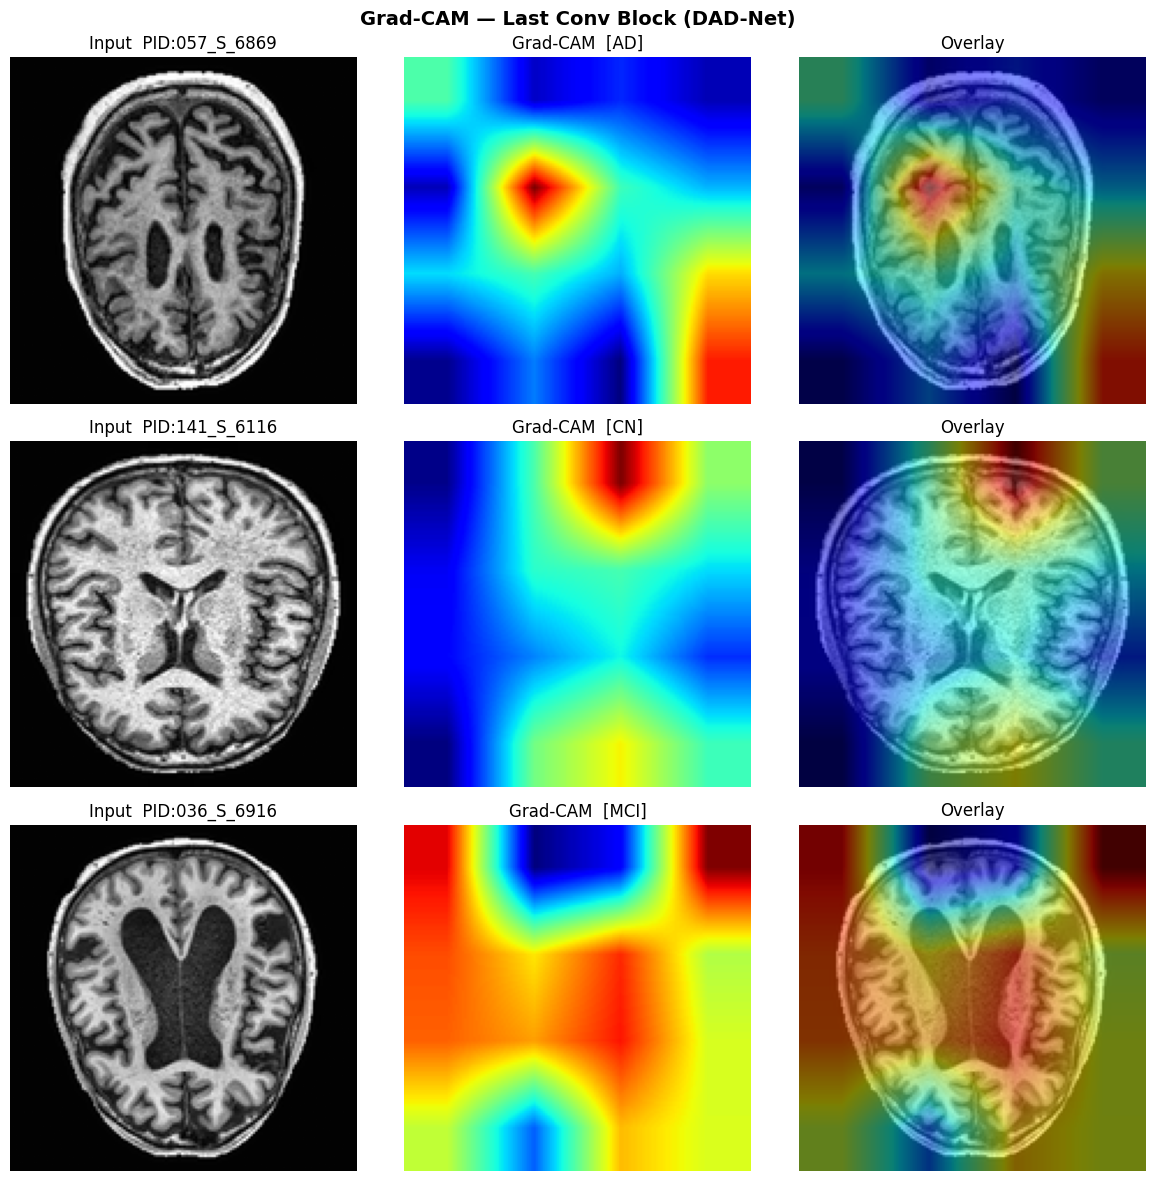

Saved → DAD_gradcam.png


In [26]:
def gradcam_heatmap(model, img_tensor, target_class, layer_idx=4):
    model.eval()
    activations, gradients = [], []
    target_layer = list(model.children())[layer_idx]

    fwd_hook = target_layer.register_forward_hook(
        lambda m, i, o: activations.append(o))
    bwd_hook = target_layer.register_full_backward_hook(
        lambda m, gi, go: gradients.append(go[0]))

    out = model(img_tensor)
    model.zero_grad()
    out[0, target_class].backward()
    fwd_hook.remove(); bwd_hook.remove()

    act     = activations[0].detach()
    grad    = gradients[0].detach()
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam     = F.relu((weights * act).sum(dim=1, keepdim=True))
    cam     = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE),
                            mode='bilinear', align_corners=False)
    cam     = cam.squeeze().cpu().numpy()
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

fig, axes = plt.subplots(len(XAI_SAMPLES), 3,
                         figsize=(12, 4 * len(XAI_SAMPLES)))
fig.suptitle('Grad-CAM — Last Conv Block (DAD-Net)', fontsize=14, fontweight='bold')

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name  = CLASS_NAMES[true_idx]
    fold_wts  = np.array(fold_results[pos_name])
    fold_wts /= fold_wts.sum()

    cam_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[pos_name], fold_wts):
        fm.to(device).eval()
        cam_accum += w * gradcam_heatmap(fm, img.unsqueeze(0).to(device), target_class=1)
        fm.to('cpu')
    cam_accum = (cam_accum - cam_accum.min()) / (cam_accum.max() - cam_accum.min() + 1e-8)

    raw   = _denorm(img)
    blend = 0.5 * raw + 0.5 * cm.jet(cam_accum)[..., :3]

    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(raw);                        ax[0].set_title(f'Input  PID:{pid[:10]}')
    ax[1].imshow(cam_accum, cmap='jet');      ax[1].set_title(f'Grad-CAM  [{pos_name}]')
    ax[2].imshow(blend);                      ax[2].set_title('Overlay')
    for a in ax: a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/DAD_gradcam.png', dpi=150)
plt.show()
print('Saved → DAD_gradcam.png')

  0%|          | 0/512 [00:00<?, ?it/s]

  0%|          | 0/512 [00:00<?, ?it/s]

  0%|          | 0/512 [00:00<?, ?it/s]

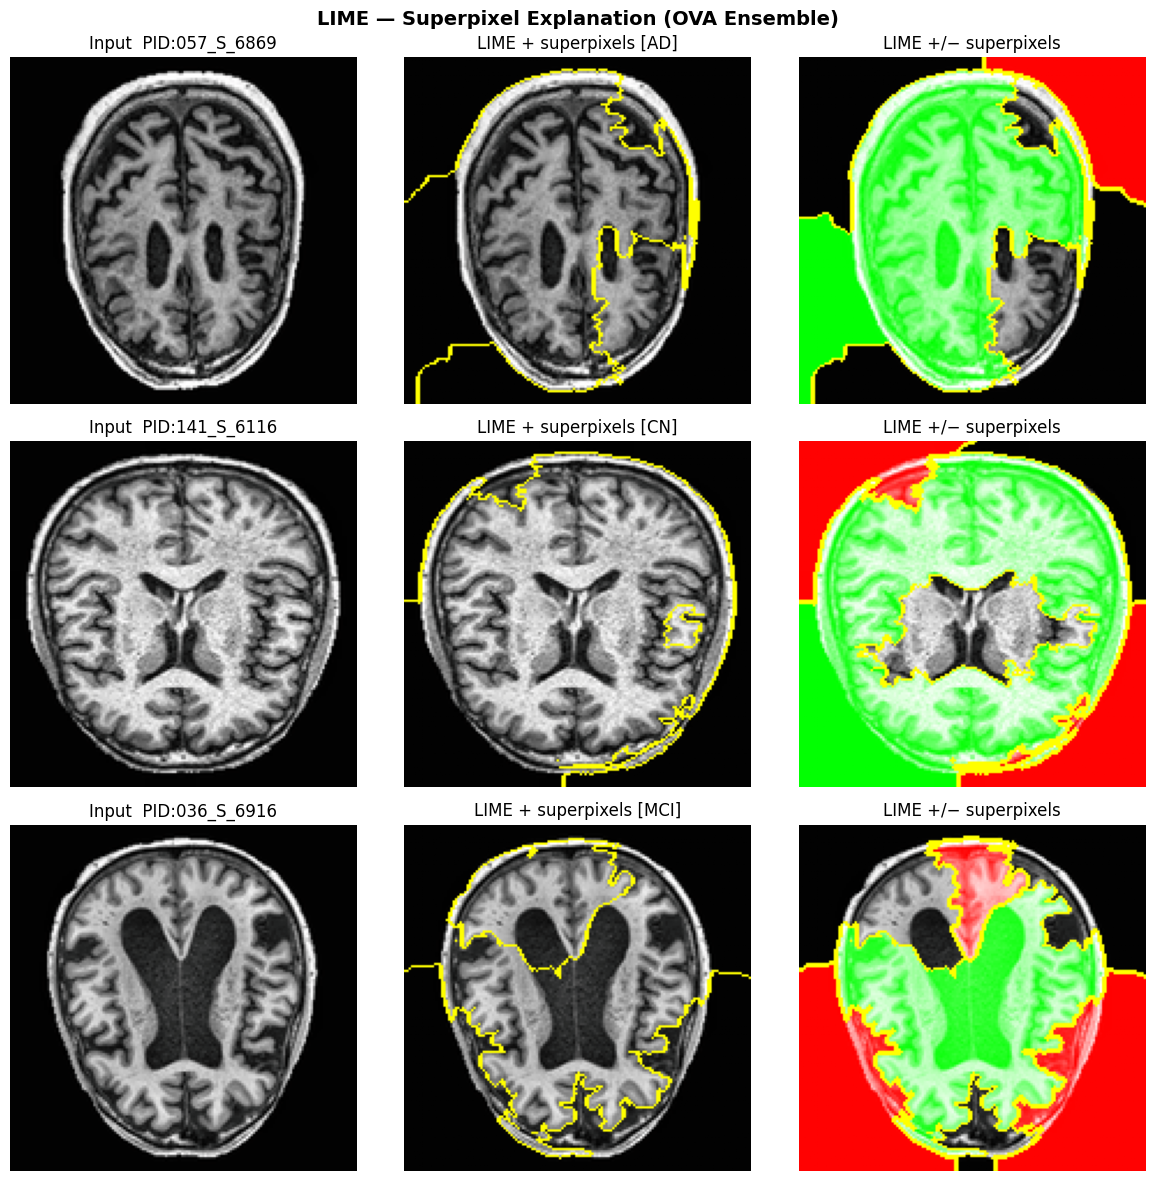

Saved → DAD_lime.png


In [29]:
def lime_predict_fn(images_np, pos_class_idx):
    norm = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    tensors = []
    for img_np in images_np:
        t = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
        tensors.append(norm(t))
    return _ensemble_forward(torch.stack(tensors), pos_class_idx).numpy()

explainer_lime = lime_image.LimeImageExplainer(random_state=42)

fig, axes = plt.subplots(len(XAI_SAMPLES), 3,
                         figsize=(12, 4 * len(XAI_SAMPLES)))
fig.suptitle('LIME — Superpixel Explanation (OVA Ensemble)', fontsize=14, fontweight='bold')

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name = CLASS_NAMES[true_idx]
    raw_np   = (_denorm(img) * 255).astype(np.uint8)

    explanation = explainer_lime.explain_instance(
        raw_np,
        classifier_fn=lambda x: lime_predict_fn(x, true_idx),
        top_labels=2, hide_color=0,
        num_samples=512,
        random_seed=42,
    )
    img_pos, mask_pos = explanation.get_image_and_mask(
        1, positive_only=True,  num_features=8, hide_rest=False)
    img_all, mask_all = explanation.get_image_and_mask(
        1, positive_only=False, num_features=8, hide_rest=False)

    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(raw_np)                                  
    ax[0].set_title(f'Input  PID:{pid[:10]}')
    ax[1].imshow(mark_boundaries(img_pos / 255.0, mask_pos))   
    ax[1].set_title(f'LIME + superpixels [{pos_name}]')
    ax[2].imshow(mark_boundaries(img_all / 255.0, mask_all)) 
    ax[2].set_title('LIME +/− superpixels')
    for a in ax: a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/DAD_lime.png', dpi=150)
plt.show()
print('Saved → DAD_lime.png')

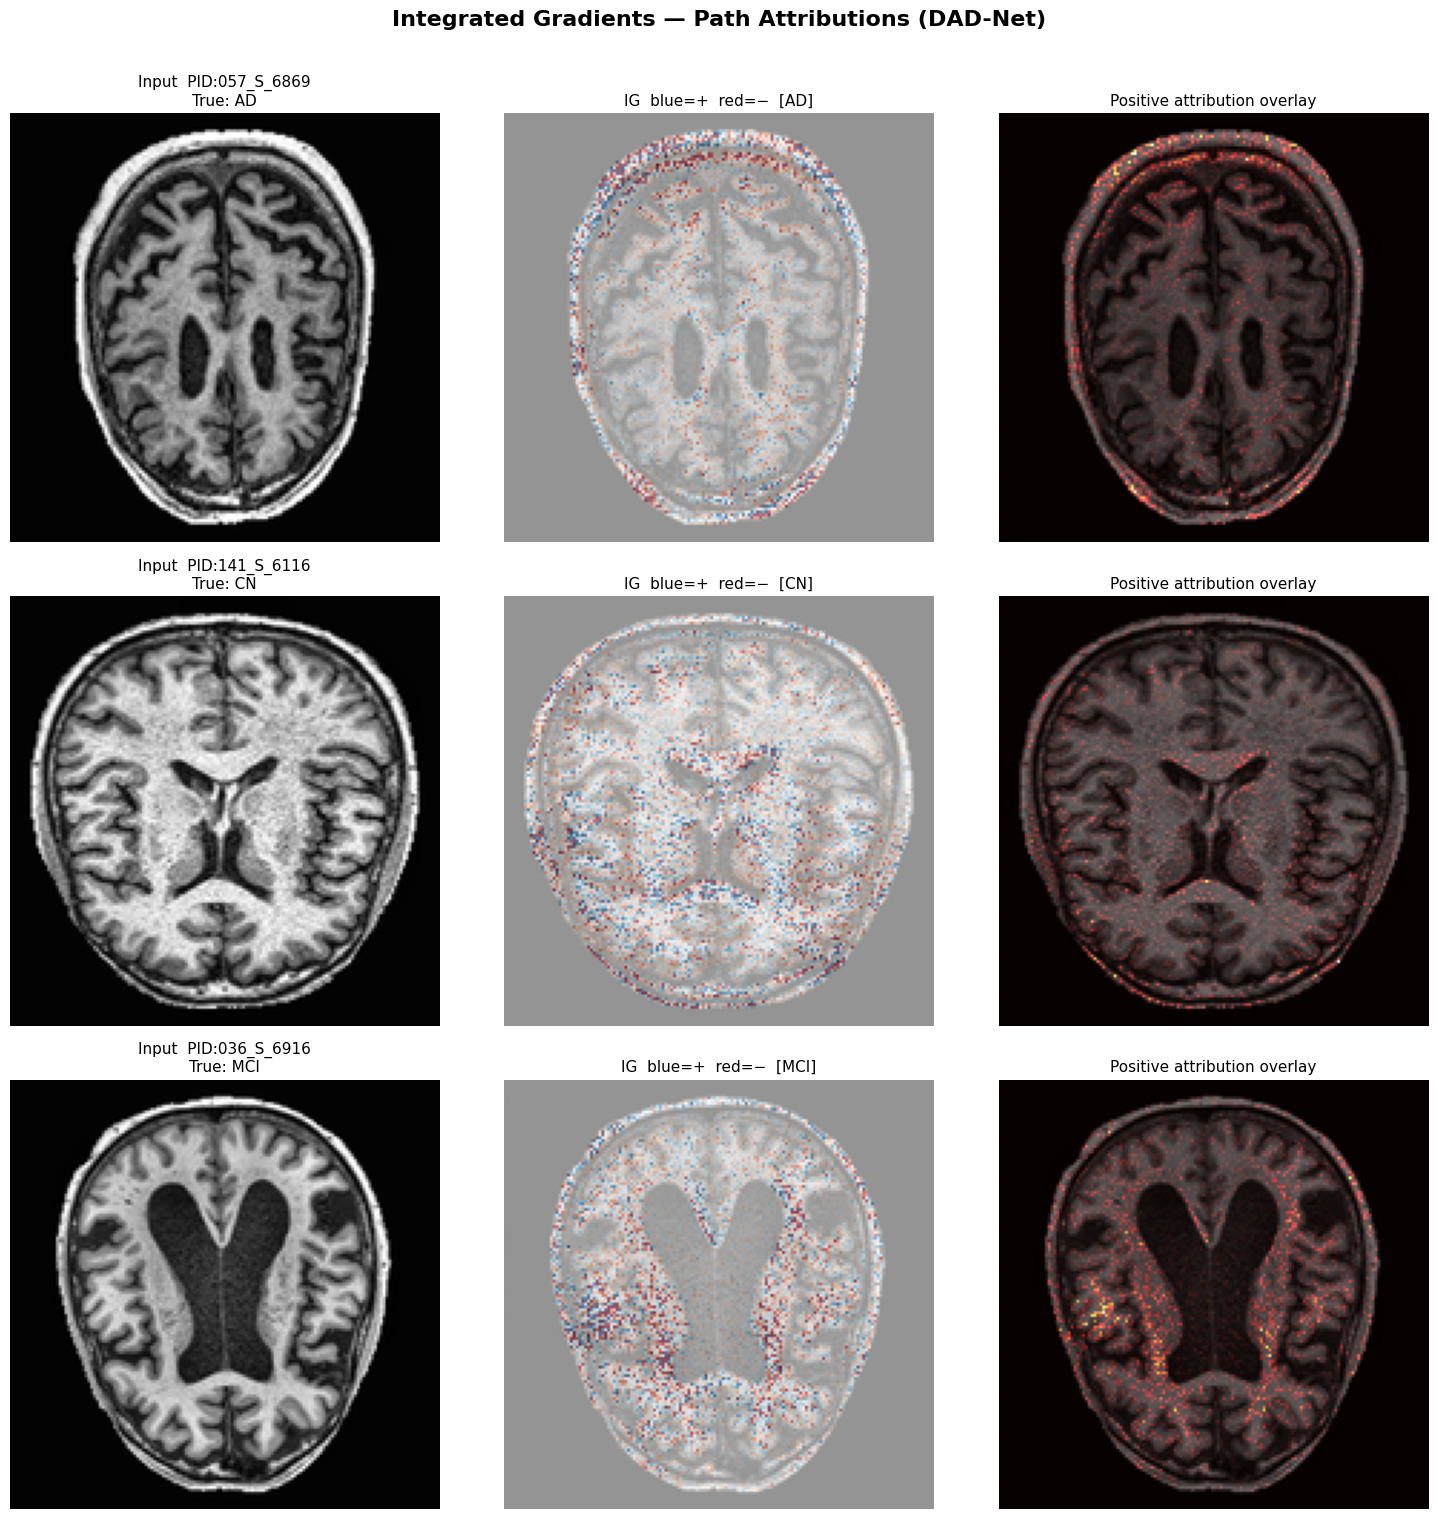

Saved → DAD_integrated_gradients.png


In [32]:
_norm_ig    = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
baseline_ig = _norm_ig(torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)).unsqueeze(0).to(device)

fig, axes = plt.subplots(len(XAI_SAMPLES), 3,
                         figsize=(15, 5 * len(XAI_SAMPLES)))
fig.suptitle('Integrated Gradients — Path Attributions (DAD-Net)',
             fontsize=16, fontweight='bold', y=1.01)

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name  = CLASS_NAMES[true_idx]
    fold_wts  = np.array(fold_results[pos_name])
    fold_wts /= fold_wts.sum()
    inp       = img.unsqueeze(0).to(device)

    ig_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[pos_name], fold_wts):
        fm.to(device).eval()
        ig   = IntegratedGradients(fm)
        attr = ig.attribute(inp, baselines=baseline_ig,
                            target=1, n_steps=50, internal_batch_size=10)
        ig_accum += w * attr.squeeze(0).mean(0).cpu().detach().numpy()
        fm.to('cpu')

    raw = _denorm(img)
    gray = raw.mean(axis=-1)

    # ── Column 0: input ───────────────────────────────────────────────────────
    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[0].set_title(f'Input  PID:{pid[:10]}\nTrue: {pos_name}', fontsize=11)

    # ── Column 1: IG signed map overlaid on brain (not on black) ─────────────
    vmax = np.percentile(np.abs(ig_accum), 99)
    ax[1].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[1].imshow(ig_accum, cmap='RdBu_r', alpha=0.6, vmin=-vmax, vmax=vmax)
    ax[1].set_title(f'IG  blue=+  red=−  [{pos_name}]', fontsize=11)

    # ── Column 2: positive attribution only overlaid on brain ─────────────────
    ig_pos = np.clip(ig_accum, 0, None)
    ig_pos = ig_pos / (ig_pos.max() + 1e-8)
    ax[2].imshow(gray, cmap='gray', vmin=0, vmax=1)
    ax[2].imshow(ig_pos, cmap='hot', alpha=0.6, vmin=0, vmax=1)
    ax[2].set_title('Positive attribution overlay', fontsize=11)

    for a in ax:
        a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/DAD_integrated_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → DAD_integrated_gradients.png')

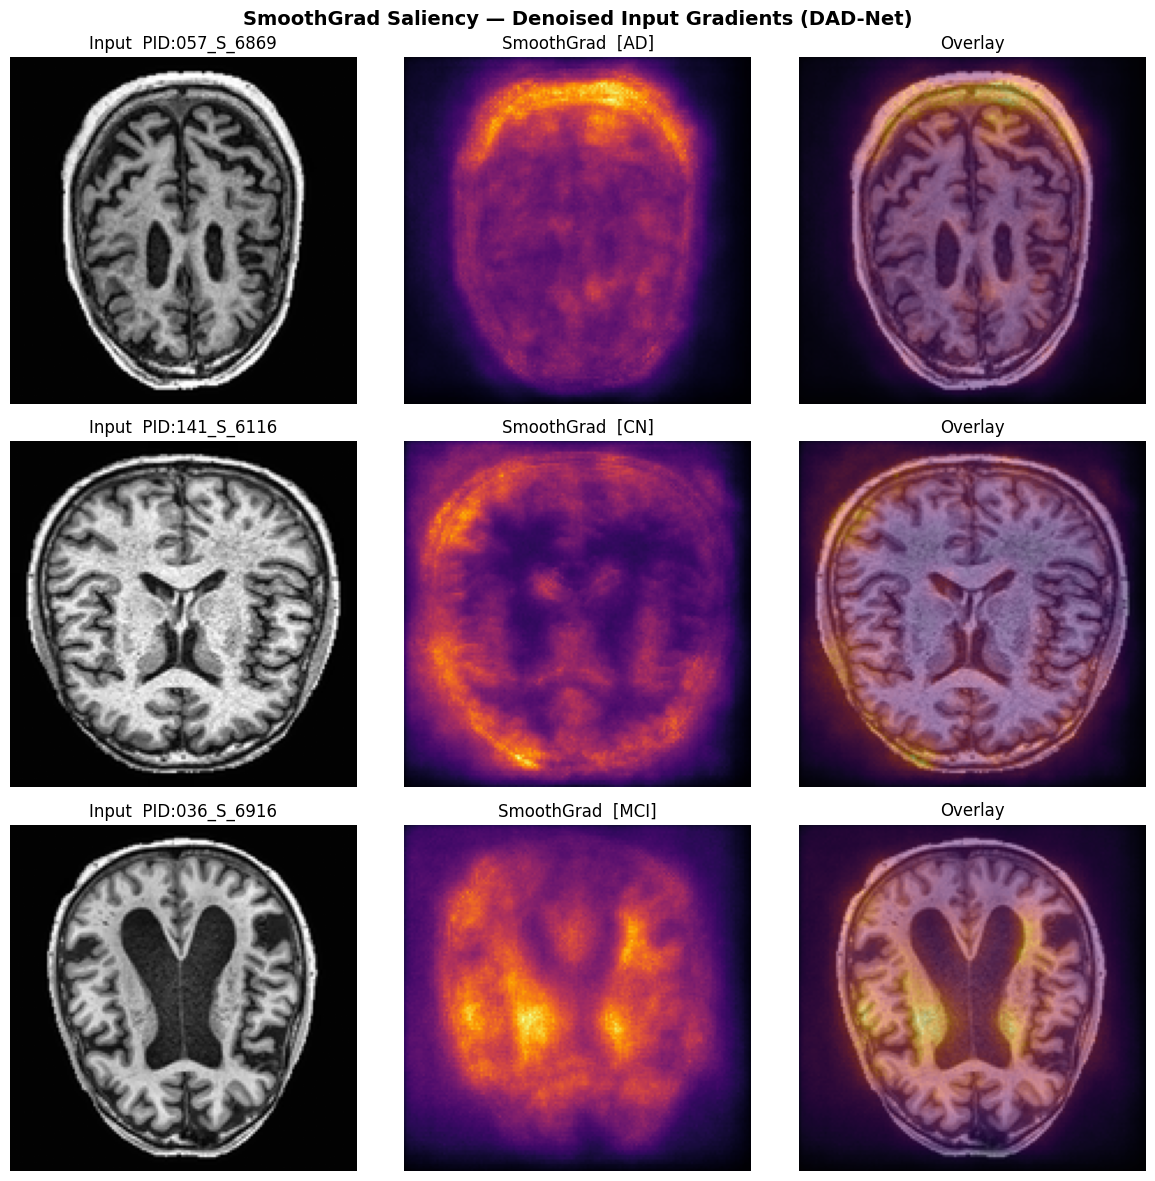

Saved → DAD_Saliency.png


In [34]:
def smoothgrad(model, img_tensor, target_class, n_samples=50, noise_level=0.15):

    model.eval()
    noise_std    = noise_level * (img_tensor.max() - img_tensor.min()).item()
    accum        = torch.zeros_like(img_tensor)

    for _ in range(n_samples):
        noisy = img_tensor + torch.randn_like(img_tensor) * noise_std
        noisy = noisy.requires_grad_(True)

        out = model(noisy)
        model.zero_grad()
        out[0, target_class].backward()

        accum += noisy.grad.detach().abs()

    avg  = (accum / n_samples).squeeze(0)         
    smap = avg.mean(dim=0).cpu().numpy()           
    smap = (smap - smap.min()) / (smap.max() - smap.min() + 1e-8)
    return smap

fig, axes = plt.subplots(len(XAI_SAMPLES), 3,
                         figsize=(12, 4 * len(XAI_SAMPLES)))
fig.suptitle('SmoothGrad Saliency — Denoised Input Gradients (DAD-Net)',
             fontsize=14, fontweight='bold')

sg_maps = []   

for row, (img, true_idx, pid) in enumerate(XAI_SAMPLES):
    pos_name  = CLASS_NAMES[true_idx]
    fold_wts  = np.array(fold_results[pos_name])
    fold_wts /= fold_wts.sum()

    sg_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[pos_name], fold_wts):
        fm.to(device).eval()
        sg_accum += w * smoothgrad(fm, img.unsqueeze(0).to(device),
                                   target_class=1,
                                   n_samples=50,
                                   noise_level=0.15)
        fm.to('cpu')

    sg_accum = (sg_accum - sg_accum.min()) / (sg_accum.max() - sg_accum.min() + 1e-8)
    sg_maps.append(sg_accum)   

    raw   = _denorm(img)
    blend = 0.5 * raw + 0.5 * cm.inferno(sg_accum)[..., :3]

    ax = axes[row] if len(XAI_SAMPLES) > 1 else axes
    ax[0].imshow(raw)
    ax[0].set_title(f'Input  PID:{pid[:10]}')
    ax[1].imshow(sg_accum, cmap='inferno')
    ax[1].set_title(f'SmoothGrad  [{pos_name}]')
    ax[2].imshow(blend)
    ax[2].set_title('Overlay')
    for a in ax: a.axis('off')

plt.tight_layout()
plt.savefig(f'{XAI_DIR}/DAD_Saliency.png', dpi=150)
plt.show()
print('Saved → DAD_Saliency.png')